# Install Dependecies

In [48]:
%%capture
%pip install -q "transformers>=5,<6"
%pip install matplotlib
%pip install ipynbname
%pip install datasets
%pip install ipywidgets

In [49]:
%%capture
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install ipykernel

# Imports

In [50]:
import numpy as np
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm.std import tqdm
from transformers import AutoTokenizer
from transformers import AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import SGDClassifier
import ipynbname
from pathlib import Path
from typing import Tuple
import time

In [51]:
ROOT_DIR = ipynbname.path().parent
ROOT_DIR = Path(ROOT_DIR)
print(ROOT_DIR)

/home/tlvj/msc_datalogi/2_semester/nlp/msc-nlp-2026/project_notebooks


# Import datasets

In [52]:
dataset = load_dataset("coastalcph/tydi_xor_rc")
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()

# Preprocessing

In [53]:
LANGUAGES = ["ar", "ko", "te"]

In [54]:
# select languages
df_train = df_train[df_train["lang"].isin(LANGUAGES)].copy()
df_val = df_val[df_val["lang"].isin(LANGUAGES)].copy()

# Tokeniser

In [55]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# 5 Week 39: Learned Answerability
Implement two classifiers that receive both question and context:
1. an interpretable learned baseline, such as logistic regression using bag-ofwords counts, overlap, length or translation-derived features; and
2. a recurrent neural classifier using learned or pretrained representations.

Complete all of the following:
* motivate the representations and the way question and context information interact;
* evaluate both models under the shared protocol and compare them with the Week 36 baselines;
* manually inspect at least ten validation errors, including false positives and false negatives from all three languages where available, create categories for recurring failure types, and report category counts with representative examples; and
* if you use the Week 38 language-model score as a feature or diagnostic, explain why it should be informative.


In [ ]:
# nlp_project_w36.ipynb
def evaluate_answerability(df, pred_column):
    rows = []
    for lang in ["all"] + LANGUAGES:
        part = df if lang == "all" else df[df["lang"] == lang]
        report = classification_report(part["answerable"], part[pred_column], labels=[True, False],
                                       target_names=["answerable", "unanswerable"], zero_division=0, output_dict=True)
        rows.append({
            "lang": lang,
            "n": len(part),
            "n_unans": int(report["unanswerable"]["support"]),
            "ans_p": report["answerable"]["precision"],
            "ans_r": report["answerable"]["recall"],
            "ans_f1": report["answerable"]["f1-score"],
            "unans_p": report["unanswerable"]["precision"],
            "unans_r": report["unanswerable"]["recall"],
            "unans_f1": report["unanswerable"]["f1-score"],
            "macro_f1": report["macro avg"]["f1-score"],
            "accuracy": report["accuracy"],
        })
    return pd.DataFrame(rows).round(3)

### Week 36 baselines

In [57]:
# nlp_project_w36.ipynb
majority_class = df_train["answerable"].mode()[0]

In [58]:
PUNCTUATION_TOKENS = {"▁", "?", "▁?", "؟", "▁؟"}

In [59]:
def rule_answerable(question, context):
    question_tokens = set(tokenizer.tokenize(question)) - PUNCTUATION_TOKENS
    context_tokens = set(tokenizer.tokenize(context))
    return len(question_tokens & context_tokens) > 0

In [63]:
# val
df_val["pred_majority"] = majority_class
df_val["pred_rule"] = [rule_answerable(question, context) for question, context in zip(df_val["question"], df_val["context"])]
display("pred_majority")
display(evaluate_answerability(df_val, "pred_majority"))
display("pred_rule")
display(evaluate_answerability(df_val, "pred_rule"))

'pred_majority'

,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,1155,164,0.858,1.0,0.924,0.0,0.0,0.0,0.462,0.858
1,ar,415,52,0.875,1.0,0.933,0.0,0.0,0.0,0.467,0.875
2,ko,356,19,0.947,1.0,0.973,0.0,0.0,0.0,0.486,0.947
3,te,384,93,0.758,1.0,0.862,0.0,0.0,0.0,0.431,0.758


'pred_rule'

,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,1155,164,0.792,0.038,0.073,0.139,0.939,0.242,0.158,0.166
1,ar,415,52,1.000,0.022,0.043,0.128,1.000,0.227,0.135,0.145
2,ko,356,19,0.842,0.047,0.090,0.047,0.842,0.090,0.090,0.090
3,te,384,93,0.667,0.048,0.090,0.237,0.925,0.377,0.233,0.260


## 1. Interpretable baseline
Such as logistic regression using bag-ofwords counts, overlap, length or translation-derived features

In [64]:
# claude
def answerability_features(question, context, lang):
    question_pieces = [piece for piece in tokenizer.tokenize(question) if piece not in PUNCTUATION_TOKENS]
    context_pieces = set(tokenizer.tokenize(context))
    overlap = [piece for piece in question_pieces if piece in context_pieces]
    features = {
        "n_overlap": len(overlap),
        "share_overlap": len(overlap) / max(len(question_pieces), 1),
        "no_overlap": len(overlap) == 0,
        "log_q_len": np.log1p(len(question_pieces)),
        "log_c_len": np.log1p(len(context_pieces)),
        f"lang={lang}": 1.0,
    }
    for piece in question_pieces:
        features[f"q={piece}"] = 1.0
    for piece in overlap:
        features[f"overlap={piece}"] = 1.0
    return features

In [65]:
# train
train_features = [answerability_features(question, context, lang) for question, context, lang in zip(df_train["question"], df_train["context"], df_train["lang"])]

In [66]:
# val
val_features = [answerability_features(question, context, lang) for question, context, lang in zip(df_val["question"], df_val["context"], df_val["lang"])]

In [67]:
# lab_2.ipynb
vectorizer = DictVectorizer(sparse=True)
X_train = vectorizer.fit_transform(train_features)
X_val = vectorizer.transform(val_features)

In [68]:
# lab_3.ipynb
def run_classifier(name, X_train, y_train, X_valid, y_valid):
    classifier = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")  # added class_weight: only ~6% of train is unanswerable
    classifier.fit(X_train, y_train)
    predictions = classifier.predict(X_valid)
    scores = {
        "model": name,
        "accuracy": accuracy_score(y_valid, predictions),
        "macro_f1": f1_score(y_valid, predictions, average="macro"),
    }
    print(name)
    print(classification_report(y_valid, predictions, digits=3))
    return classifier, predictions, scores

In [69]:
start = time.time()
lr_model, lr_predictions, lr_scores = run_classifier(
    "Logistic regression", X_train, df_train["answerable"], X_val, df_val["answerable"]
)
print(f"training time: {time.time() - start:.1f}s | examples: {X_train.shape[0]} | features: {X_train.shape[1]}")

Logistic regression
              precision    recall  f1-score   support

       False      0.685     0.768     0.724       164
        True      0.961     0.941     0.951       991

    accuracy                          0.917      1155
   macro avg      0.823     0.855     0.838      1155
weighted avg      0.922     0.917     0.919      1155

training time: 0.1s | examples: 6335 | features: 7696


In [70]:
# train
df_train["pred_lr"] = lr_model.predict(X_train)
evaluate_answerability(df_train, "pred_lr")

,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,6335,363,1.0,0.986,0.993,0.816,1.0,0.899,0.946,0.987
1,ar,2558,255,1.0,0.970,0.985,0.789,1.0,0.882,0.934,0.973
2,ko,2422,63,1.0,0.997,0.999,0.900,1.0,0.947,0.973,0.997
3,te,1355,45,1.0,0.995,0.997,0.865,1.0,0.928,0.963,0.995


In [71]:
# val
df_val["pred_lr"] = lr_predictions
evaluate_answerability(df_val, "pred_lr")

,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,1155,164,0.961,0.941,0.951,0.685,0.768,0.724,0.838,0.917
1,ar,415,52,0.994,0.983,0.989,0.893,0.962,0.926,0.957,0.981
2,ko,356,19,0.971,1.000,0.985,1.000,0.474,0.643,0.814,0.972
3,te,384,93,0.902,0.821,0.860,0.563,0.720,0.632,0.746,0.797


### Most informative features
positive weights -> answerable \
negative weights -> unanswerable.

In [72]:
# lab_3.ipynb
feature_names = vectorizer.get_feature_names_out()
weights = lr_model.coef_[0]

top_negative = feature_names[np.argsort(weights)[:15]]
top_positive = feature_names[np.argsort(weights)[-15:][::-1]]
pd.DataFrame({"negative": top_negative, "positive": top_positive})

,negative,positive
0,q=▁هل,q=▁언제
1,q=컨,q=▁몇
2,q=▁ముఖ్యమంత్రి,q=▁어디
3,q=▁베이,q=▁무엇인가
4,q=▁علوم,q=▁어느
5,q=▁తమిళనాడు,q=▁누구
6,q=룰,q=▁가장
7,q=▁있을까,q=تى
8,q=దేశం,q=▁누가
9,q=ష్,q=▁얼마나


### Errors (val)

In [73]:
# lab_3.ipynb
lr_error_table = df_val.copy()
lr_error_table["prediction"] = lr_predictions
lr_error_table = lr_error_table[
    lr_error_table["answerable"] != lr_error_table["prediction"]
]
lr_error_table[["lang", "question", "answerable", "prediction"]].head(10)

,lang,question,answerable,prediction
0,te,ఒరెగాన్ రాష్ట్రంలోని అతిపెద్ద నగరం ఏది ?,True,False
1,te,కలరా వ్యాధిని మొదటగా ఏ దేశంలో కనుగొన్నారు ?,True,False
2,te,కలరా వ్యాధిని మొదటగా ఏ దేశంలో కనుగొన్నారు ?,True,False
8,te,టెక్సస్ రాష్ట్రంలోని అతిపెద్ద మానవ నిర్మితం ఏది ?,True,False
17,te,ఉగాండా ఏ ఖండంలో ఉంది?,True,False
18,te,ఖురాన్ ఏ అరబ్బీ భాషలో ఎవరు రాసారు?,True,False
22,te,ఒక మనిషి సగటుగా ఎంత ఉష్ణోగ్రతని తట్టుకోగలడు?,True,False
26,te,మనిషి చనిపోయాక ఏ అవయవం ఎక్కువ సమయం పనిచేస్తుంది?,True,False
39,te,బ్రిటిష్ పాలనలో సగటున ఎంతమంది భారతీయులు మరణించ...,True,False
48,te,నీరు ఆవిరిగా మారడానికి ఎంత ఉష్ణోగ్రత కావాలి?,True,False


## recurrent neural classifier 
using learned or pretrained representations

In [ ]:
# lab_5.ipynb
def enforce_reproducibility(seed=42):
    # Sets seed manually for both CPU and CUDA
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For atomic operations there is currently
    # no simple way to enforce determinism, as
    # the order of parallel operations is not known.
    # CUDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # System based
    random.seed(seed)
    np.random.seed(seed)
enforce_reproducibility()

In [76]:
# lab_5.ipynb
device = torch.device("cpu")
if torch.cuda.is_available():
  device = torch.device("cuda")
device

device(type='cuda')

In [ ]:
# lab_5.ipynb
# Define some hyperparameters
lr = 0.001
n_epochs = 5
lstm_dim = 128
lstm_layers = 1
batch_size = 32
seq_len = 256

### Embeddings

In [78]:
# lab_5.ipynb
xlmr = AutoModel.from_pretrained("xlm-roberta-base")
# Extract the embeddings and add a randomly initialized embedding for our extra [PAD] token
pretrained_embeddings = np.concatenate([xlmr.get_input_embeddings().weight.detach().numpy(), np.zeros(shape=(1, 768))], axis=0)
# Extract the vocab and add an extra [PAD] token
vocabulary = tokenizer.convert_ids_to_tokens(list(range(len(tokenizer)))) + ['[PAD]']
del xlmr

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [79]:
# lab_5.ipynb
print("embeddings' shape:", pretrained_embeddings.shape, "vocabulary size:", len(vocabulary))

embeddings' shape: (250003, 768) vocabulary size: 250003


### Data

In [80]:
# lab_5.ipynb
def tokenize_function(examples):
    return tokenizer(examples["question"], examples["context"], truncation="only_second", max_length=seq_len)

answerability_datasets = dataset.filter(lambda example: example["lang"] in LANGUAGES)
tokenized_datasets = answerability_datasets.map(tokenize_function, batched=True, remove_columns=["question", "context", "lang", "answer_start", "answer", "answer_inlang"])
print(tokenized_datasets['train'][3]['input_ids'][:10])

Filter:   0%|          | 0/15343 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4 [00:00<?, ? examples/s]

Map:   0%|          | 0/6335 [00:00<?, ? examples/s]

Map:   0%|          | 0/1155 [00:00<?, ? examples/s]

[0, 61673, 1180, 13968, 110903, 5191, 47576, 84200, 227539, 32]


In [82]:
# lab_5.ipynb
PAD_ID = len(vocabulary) - 1

def collate_batch_bilstm(dataset) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Combines multiple data samples into a single batch
    :param input_ids: The token input ids
    :return: A tuple of tensors (input_ids, input_lengths, targets)
    """
    input_ids = [i['input_ids'] for i in dataset]
    targets = [int(i['answerable']) for i in dataset]

    input_lengths, padded_input = [], []
    for sentence in input_ids:
      sentence = sentence[:seq_len]
      input_lengths.append(len(sentence))
      sentence = sentence + [PAD_ID] * (seq_len - len(sentence))
      padded_input.append(sentence)

    input_data = torch.tensor(padded_input)

    return input_data, torch.tensor(input_lengths), torch.tensor(targets)

In [83]:
# lab_5.ipynb (added shuffle for the training data)
train_dl = torch.utils.data.DataLoader(tokenized_datasets['train'], batch_size=batch_size, shuffle=True, collate_fn=collate_batch_bilstm)
valid_dl = torch.utils.data.DataLoader(tokenized_datasets['validation'], batch_size=batch_size, collate_fn=collate_batch_bilstm)

### Model

In [84]:
# lab_5.ipynb
class LSTM_Classifier(nn.Module):
    """
    LSTM Language Model
    """
    def __init__(
            self,
            pretrained_embeddings: torch.tensor,
            lstm_dim: int,
            dropout_prob: float = 0.0,
            lstm_layers: int = 1,
            n_classes: int = 2,
    ):
        """
        Initializer for the BiLSTM classifier
        :param pretrained_embeddings: A tensor containing the pretrained XLM-R embeddings
        :param lstm_dim: The dimensionality of the BiLSTM network
        :param dropout_prob: Dropout probability
        :param lstm_layers: The number of stacked LSTM layers
        :param n_classes: The number of output classes (unanswerable, answerable)
        """

        # First thing is to call the superclass initializer
        super(LSTM_Classifier, self).__init__()

        # We'll define the network in a ModuleDict, which makes organizing the model a bit nicer
        # The components are an embedding layer, an LSTM layer, a dropout layer, and a feed-forward output layer
        self.model = nn.ModuleDict({
            'embeddings': nn.Embedding.from_pretrained(pretrained_embeddings, padding_idx=pretrained_embeddings.shape[0] - 1),
            'lstm': nn.LSTM(
                pretrained_embeddings.shape[1],
                lstm_dim,
                num_layers=lstm_layers,
                batch_first=True,
                dropout=dropout_prob,
                bidirectional=True),
            'ff': nn.Linear(2 * lstm_dim, n_classes),  # changed: one score per class
            'drop': nn.Dropout(dropout_prob)
        })

        # Initialize the weights of the model
        self._init_weights()

    def _init_weights(self):
        all_params = list(self.model['lstm'].named_parameters()) + \
                     list(self.model['ff'].named_parameters())
        for n, p in all_params:
            if 'weight' in n:
                nn.init.xavier_normal_(p)
            elif 'bias' in n:
                nn.init.zeros_(p)

    def forward(self, input_ids, input_lens):
        """
        Defines how tensors flow through the model
        :param input_ids: (b x sl) The IDs into the vocabulary of the input samples
        :param input_lens: (b x 1) The length of each instance's text
        :return: (b x n_classes) logits
        """

        # Get embeddings (b x sl x edim)
        embeds = self.model['drop'](self.model['embeddings'](input_ids))

        lstm_in = nn.utils.rnn.pack_padded_sequence(
            embeds,
            input_lens.to('cpu'),
            batch_first=True,
            enforce_sorted=False
        )

        # Pass the packed sequence through the BiLSTM
        lstm_out, hidden = self.model['lstm'](lstm_in)
        # changed: classify from the last hidden vector of each direction (lab_5 step 9: "just pick last hidden vector")
        # forward direction has read question -> context, backward direction context -> question
        final_hidden = torch.cat([hidden[0][-2], hidden[0][-1]], dim=-1)
        final_hidden = self.model['drop'](final_hidden)
        return self.model['ff'](final_hidden)

### Training-day

In [85]:
# class-weighted loss, same weights as class_weight="balanced": n / (2 * n_class)
class_counts = df_train["answerable"].value_counts()
class_weights = torch.tensor([len(df_train) / (2 * class_counts[False]), len(df_train) / (2 * class_counts[True])], dtype=torch.float)
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))
class_weights

tensor([8.7259, 0.5304])

In [96]:
# lab_4.ipynb
def evaluate(model: nn.Module, valid_dl: DataLoader):
    """
    Evaluates the model on the given dataset
    :param model: The model under evaluation
    :param valid_dl: A `DataLoader` reading validation data
    :return: The macro F1 and the mean loss of the model on the dataset
    :return: The accuracy of the model on the dataset
    """
    # VERY IMPORTANT: Put your model in "eval" mode -- this disables things like
    # layer normalization and dropout
    model.eval()
    labels_all = []
    logits_all = []
    losses_all = []
    # ALSO IMPORTANT: Don't accumulate gradients during this process
    with torch.no_grad():
        for batch in tqdm(valid_dl, desc='Evaluation'):
            batch = tuple(t.to(device) for t in batch)
            input_ids = batch[0]
            input_lens = batch[1]
            labels = batch[2]

            logits = model(input_ids, input_lens)
            loss = loss_fn(logits, labels)
            labels_all.extend(list(labels.detach().cpu().numpy()))
            logits_all.extend(list(logits.detach().cpu().numpy()))
            losses_all.append(loss.detach().cpu().numpy())
        macro_f1 = f1_score(labels_all, np.argmax(logits_all, axis=-1), average="macro")

        return macro_f1, np.mean(losses_all)

In [97]:
# lab_6.ipynb
def predict(model: nn.Module, valid_dl: DataLoader):
    """
    Evaluates the model on the given dataset
    :param model: The model under evaluation
    :param valid_dl: A `DataLoader` reading validation data
    :return: The accuracy of the model on the dataset
    """
    # VERY IMPORTANT: Put your model in "eval" mode -- this disables things like
    # layer normalization and dropout
    model.eval()
    preds_all = []

    # ALSO IMPORTANT: Don't accumulate gradients during this process
    with torch.no_grad():
        for batch in tqdm(valid_dl, desc='Evaluation'):
            batch = tuple(t.to(device) for t in batch)
            logits = model(batch[0], batch[1])
            preds_all.extend(list(logits.argmax(dim=-1).detach().cpu().numpy()))

    return np.array(preds_all, dtype=bool)

In [ ]:
# lab_4.ipynb (best model on macro F1)
def train(
    model: nn.Module,
    train_dl: DataLoader,
    valid_dl: DataLoader,
    optimizer: torch.optim.Optimizer,
    n_epochs: int,
    device: torch.device
):
    """
    The main training loop which will optimize a given model on a given dataset
    :param model: The model being optimized
    :param train_dl: The training dataset
    :param valid_dl: A validation dataset
    :param optimizer: The optimizer used to update the model parameters
    :param n_epochs: Number of epochs to train for
    :param device: The device to train on
    :return: (model, losses) The best model and the losses per iteration
    """

    # Keep track of the loss and best macro F1
    losses = []
    best_f1 = 0.0
    best_model = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}

    # Iterate through epochs
    for ep in range(n_epochs):

        loss_epoch = []

        #Iterate through each batch in the dataloader
        for i, batch in tqdm(enumerate(train_dl)):
            # VERY IMPORTANT: Make sure the model is in training mode, which turns on
            # things like dropout and layer normalization
            model.train()

            # VERY IMPORTANT: zero out all of the gradients on each iteration -- PyTorch
            # keeps track of these dynamically in its computation graph so you need to explicitly
            # zero them out
            optimizer.zero_grad()

            # Place each tensor on the GPU
            batch = tuple(t.to(device) for t in batch)
            input_ids = batch[0]
            input_lens = batch[1]
            labels = batch[2]

            # Pass the inputs through the model, get the current loss and logits
            logits = model(input_ids, input_lens)
            loss = loss_fn(logits, labels)
            losses.append(loss.item())
            loss_epoch.append(loss.item())

            # Calculate all of the gradients and weight updates for the model
            loss.backward()

            # Optional: clip gradients, helps with exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Finally, update the weights of the model
            optimizer.step()

        # Perform inline evaluation at the end of the epoch
        macro_f1, val_loss = evaluate(model, valid_dl)
        print(f'Validation macro F1: {macro_f1}, train loss: {np.mean(loss_epoch)}, val loss: {val_loss}')

        # Keep track of the best model based on the macro F1
        if macro_f1 > best_f1:
            best_model = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
            best_f1 = macro_f1

    model.load_state_dict(best_model)
    return model, losses

In [ ]:
# lab_5.ipynb
enforce_reproducibility(42)
model = LSTM_Classifier(
    torch.FloatTensor(pretrained_embeddings),
    lstm_dim=lstm_dim,
    dropout_prob=0.1,
    lstm_layers=lstm_layers
  ).to(device)

# Create the optimizer
optimizer = Adam(model.parameters(), lr=lr)

# Train
start = time.time()
model, losses = train(model, train_dl, valid_dl, optimizer, n_epochs, device)
print(f"training time: {time.time() - start:.1f}s | examples: {len(tokenized_datasets['train'])} | epochs: {n_epochs}")

/home/tlvj/anaconda3/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
198it [00:07, 26.21it/s]
198it [00:06, 29.21it/s]
198it [00:06, 28.84it/s]
198it [00:06, 29.19it/s]
198it [00:06, 28.80it/s]
Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 47.39it/s]


Validation macro F1: 0.8164357274878449, train loss: 0.17072386335525097, val loss: 0.7581844925880432
training time: 37.2s | examples: 6335 | epochs: 5


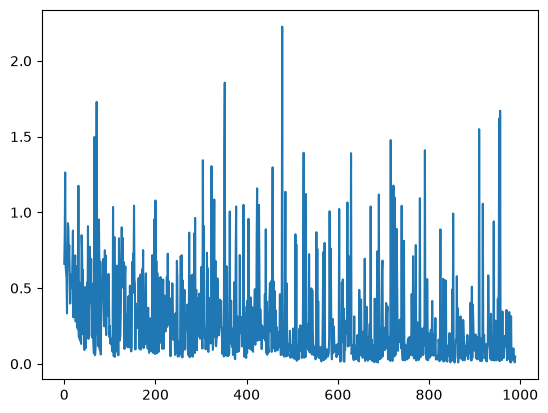

In [91]:
# lab_5.ipynb
plt.plot(losses)

In [92]:
# train
train_eval_dl = torch.utils.data.DataLoader(tokenized_datasets['train'], batch_size=batch_size, collate_fn=collate_batch_bilstm)
df_train["pred_bilstm"] = predict(model, train_eval_dl)
evaluate_answerability(df_train, "pred_bilstm")

Evaluation: 100%|████████████████████████████████████████████████████████████████████| 198/198 [00:04<00:00, 48.88it/s]


,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,6335,363,0.999,0.977,0.988,0.721,0.981,0.831,0.909,0.977
1,ar,2558,255,1.000,0.956,0.978,0.716,1.000,0.835,0.906,0.961
2,ko,2422,63,0.998,0.990,0.994,0.711,0.937,0.808,0.901,0.988
3,te,1355,45,0.998,0.990,0.994,0.764,0.933,0.840,0.917,0.988


In [93]:
# val
df_val["pred_bilstm"] = predict(model, valid_dl)
evaluate_answerability(df_val, "pred_bilstm")

Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 43.36it/s]


,lang,n,n_unans,ans_p,ans_r,ans_f1,unans_p,unans_r,unans_f1,macro_f1,accuracy
0,all,1155,164,0.954,0.936,0.945,0.654,0.726,0.688,0.816,0.906
1,ar,415,52,0.994,0.959,0.976,0.769,0.962,0.855,0.915,0.959
2,ko,356,19,0.951,0.985,0.968,0.286,0.105,0.154,0.561,0.938
3,te,384,93,0.905,0.852,0.878,0.609,0.720,0.660,0.769,0.820


### Seeds
`seed = [42, 43, 44]`

In [94]:
# claude
seed_scores = []
for seed in [42, 43, 44]:
    enforce_reproducibility(seed)
    seed_model = LSTM_Classifier(torch.FloatTensor(pretrained_embeddings), lstm_dim=lstm_dim, dropout_prob=0.1, lstm_layers=lstm_layers).to(device)
    seed_model, _ = train(seed_model, train_dl, valid_dl, Adam(seed_model.parameters(), lr=lr), n_epochs, device)
    df_val["pred_seed"] = predict(seed_model, valid_dl)
    seed_scores.append(evaluate_answerability(df_val, "pred_seed"))

pd.concat(seed_scores).groupby("lang", sort=False)[["ans_f1", "unans_f1", "macro_f1"]].agg(["mean", "std"]).round(3)

/home/tlvj/anaconda3/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
198it [00:07, 27.80it/s]
198it [00:06, 28.73it/s]
198it [00:06, 28.75it/s]
198it [00:06, 28.87it/s]
198it [00:06, 29.00it/s]
Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 47.40it/s]


Validation macro F1: 0.8164357274878449, train loss: 0.17072386335525097, val loss: 0.7581844925880432


Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 53.09it/s]
/home/tlvj/anaconda3/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
198it [00:06, 28.34it/s]
198it [00:06, 28.75it/s]
198it [00:06, 29.06it/s]
198it [00:06, 29.24it/s]
198it [00:06, 29.17it/s]
Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 48.51it/s]


Validation macro F1: 0.8007246376811594, train loss: 0.1203132633383226, val loss: 0.815850019454956


Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 50.83it/s]
/home/tlvj/anaconda3/lib/python3.14/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
198it [00:07, 28.04it/s]
198it [00:06, 29.02it/s]
198it [00:06, 28.75it/s]
198it [00:07, 28.22it/s]
198it [00:07, 28.05it/s]
Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 45.56it/s]


Validation macro F1: 0.7949332534371982, train loss: 0.1431319057762698, val loss: 0.8943314552307129


Evaluation: 100%|██████████████████████████████████████████████████████████████████████| 37/37 [00:00<00:00, 48.43it/s]


ans_f1        unans_f1        macro_f1       
       mean    std     mean    std     mean    std
lang                                              
all   0.938  0.006    0.670  0.016    0.804  0.011
ar    0.984  0.007    0.899  0.039    0.941  0.023
ko    0.946  0.019    0.132  0.043    0.539  0.027
te    0.868  0.009    0.655  0.006    0.761  0.007

## Comparison with the week 36 baselines
macro f1 overall and per language

In [95]:
# claude
models = {"majority": "pred_majority", "rule": "pred_rule", "logistic regression": "pred_lr", "bilstm": "pred_bilstm"}
comparison = pd.DataFrame({name: evaluate_answerability(df_val, column).set_index("lang")["macro_f1"] for name, column in models.items()}).T
comparison.columns = [f"{lang} (n={n})" for lang, n in zip(comparison.columns, evaluate_answerability(df_val, "pred_majority")["n"])]
comparison

,all (n=1155),ar (n=415),ko (n=356),te (n=384)
majority,0.462,0.467,0.486,0.431
rule,0.158,0.135,0.090,0.233
logistic regression,0.838,0.957,0.814,0.746
bilstm,0.816,0.915,0.561,0.769
